In [1]:
# =========================
# Cell 1: Setup & Paths
# =========================
import os, random, json
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)

BASE_DIR = "/content/drive/MyDrive/CSE499A_Project"
W4_DIR   = f"{BASE_DIR}/Week4"
INP_DIR  = f"{BASE_DIR}/Week3/inputs"      # reuse Week-3 images
RES_DIR  = f"{W4_DIR}/results"
LOG_DIR  = f"{W4_DIR}/logs"
CKPT_DIR = f"{W4_DIR}/checkpoints"

for d in [BASE_DIR, W4_DIR, RES_DIR, LOG_DIR, CKPT_DIR]:
    os.makedirs(d, exist_ok=True)

print("Week4 paths ready:", W4_DIR)


Mounted at /content/drive
Week4 paths ready: /content/drive/MyDrive/CSE499A_Project/Week4


In [2]:
# =========================
# Cell 2: Installs & Imports
# =========================
!pip -q install einops==0.8.0

import math, numpy as np
import torch, torchvision
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, utils as vutils
import matplotlib.pyplot as plt
from einops import rearrange


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.2/43.2 kB 2.8 MB/s eta 0:00:00


In [3]:
# =========================
# Cell 3: Device & Seed
# =========================
def seed_everything(s=123):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False

seed_everything(123)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
# =========================
# Cell 4: Data Loader (reuse Week-3 inputs)
# =========================
IMG_SIZE = 256
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)  # [-1,1]
])

dataset = datasets.ImageFolder(root=INP_DIR, transform=transform)
print("Found images:", len(dataset))
BATCH_SIZE = 4
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                    num_workers=2, pin_memory=(device.type=='cuda'))

def denorm(x): return (x.clamp(-1,1)+1)*0.5


Found images: 4


In [5]:
# =========================
# Cell 5: Time Embeddings + U-Net (with t embedding)
# =========================
class SinusoidalTime(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        # t: [B] long
        half = self.dim//2
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device).float()/half)
        args = t[:,None].float()*freqs[None,:]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb  # [B, dim]

def conv3x3(ic, oc): return nn.Conv2d(ic, oc, 3, padding=1)

class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.GroupNorm(8, ch), nn.SiLU(), conv3x3(ch, ch),
            nn.GroupNorm(8, ch), nn.SiLU(), conv3x3(ch, ch),
        )
    def forward(self, x): return x + self.net(x)

class Down(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.conv = conv3x3(ic, oc)
        self.res  = ResBlock(oc)
        self.pool = nn.Conv2d(oc, oc, 4, stride=2, padding=1)
    def forward(self, x):
        x = self.conv(x); x = self.res(x); skip = x
        x = self.pool(x); return x, skip

class Up(nn.Module):
    def __init__(self, ic, oc):
        super().__init__()
        self.up  = nn.ConvTranspose2d(ic, oc, 4, stride=2, padding=1)
        self.mix = conv3x3(oc*2, oc)
        self.res = ResBlock(oc)
    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], 1)
        x = self.mix(x); x = self.res(x); return x

class UNetDenoiser(nn.Module):
    """
    Baseline U-Net + simple time conditioning:
    - sinusoidal t embedding -> MLP -> added at mid layer
    """
    def __init__(self, in_ch=3, base=64, t_dim=256):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinusoidalTime(t_dim),
            nn.Linear(t_dim, base*8), nn.SiLU(),
            nn.Linear(base*8, base*8)
        )
        self.enc1 = Down(in_ch, base)        # 256->128
        self.enc2 = Down(base, base*2)       # 128->64
        self.enc3 = Down(base*2, base*4)     # 64->32
        self.mid0 = conv3x3(base*4, base*8)
        self.mid1 = ResBlock(base*8)
        self.up3  = Up(base*8, base*4)
        self.up2  = Up(base*4, base*2)
        self.up1  = Up(base*2, base)
        self.head = nn.Sequential(nn.GroupNorm(8, base), nn.SiLU(), conv3x3(base, 3))

    def forward(self, x, t):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        h = self.mid0(x3)
        temb = self.time_emb(t).view(t.size(0), -1, 1, 1)
        h = h + temb
        h = self.mid1(h)
        h = self.up3(h, s3)
        h = self.up2(h, s2)
        h = self.up1(h, s1)
        return self.head(h)

model = UNetDenoiser(in_ch=3, base=64).to(device)
print("UNetDenoiser params:", sum(p.numel() for p in model.parameters())/1e6, "M")


UNetDenoiser params: 15.449091 M


In [6]:
# =========================
# Cell 6: Schedules & Forward Diffusion
# =========================
def make_beta_schedule(T=1000, beta_start=1e-4, beta_end=0.02, kind="linear"):
    if kind == "linear":
        return torch.linspace(beta_start, beta_end, T)
    elif kind == "cosine":
        # Nichol & Dhariwal cosine schedule
        s=0.008
        t=torch.linspace(0,1,T+1)
        alphas_cum = torch.cos(((t+s)/(1+s))*math.pi*0.5)**2
        alphas_cum = alphas_cum/alphas_cum[0]
        betas = 1 - (alphas_cum[1:]/alphas_cum[:-1])
        return betas.clamp(1e-8, 0.999)
    else:
        raise ValueError("Unknown schedule")

T = 1000
betas = make_beta_schedule(T, kind="linear").to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)             # \bar{alpha}_t
sqrt_alphas_cum = torch.sqrt(alphas_cumprod)
sqrt_one_minus = torch.sqrt(1.0 - alphas_cumprod)

@torch.no_grad()
def preview_noising(batch, ts=[50,300,800], save_path=f"{RES_DIR}/week4_forward_noising.png"):
    b = batch.size(0)
    fig, axes = plt.subplots(1, len(ts)+1, figsize=(4*(len(ts)+1), 4))
    axes[0].imshow(denorm(batch[0]).permute(1,2,0).cpu().numpy()); axes[0].set_title("x0"); axes[0].axis('off')
    for i,tt in enumerate(ts, start=1):
        t = torch.full((b,), tt, device=device, dtype=torch.long)
        eps = torch.randn_like(batch)
        xt = sqrt_alphas_cum[tt].view(1,1,1,1)*batch + sqrt_one_minus[tt].view(1,1,1,1)*eps
        axes[i].imshow(denorm(xt[0]).permute(1,2,0).cpu().numpy()); axes[i].set_title(f"t={tt}"); axes[i].axis('off')
    plt.tight_layout(); plt.savefig(save_path, dpi=120); plt.close(fig)
    print("Saved:", save_path)

# make a quick noising preview
xb = next(iter(loader))[0].to(device)
preview_noising(xb)


Saved: /content/drive/MyDrive/CSE499A_Project/Week4/results/week4_forward_noising.png


In [7]:
# =========================
# Cell 7: Training Loop (predict epsilon)
# =========================
model.train()
optim = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

EPOCHS   = 2            # keep small for Colab; increase if you want
MAX_STEPS= 600          # budget; increase for better results
LOG_EVERY= 50

global_step = 0
losses = []

def train_step(x0):
    b = x0.size(0)
    t = torch.randint(low=0, high=T, size=(b,), device=device, dtype=torch.long)
    noise = torch.randn_like(x0)
    a_bar = alphas_cumprod[t].view(b,1,1,1)
    xt = torch.sqrt(a_bar)*x0 + torch.sqrt(1.0-a_bar)*noise
    pred = model(xt, t)               # predict noise
    loss = criterion(pred, noise)
    return loss

for ep in range(EPOCHS):
    for batch in loader:
        x0 = batch[0].to(device)
        optim.zero_grad()
        loss = train_step(x0)
        loss.backward()
        optim.step()

        global_step += 1
        losses.append(loss.item())
        if global_step % LOG_EVERY == 0:
            print(f"[Ep {ep+1}] step {global_step} | loss {loss.item():.4f}")
        if global_step >= MAX_STEPS:
            break
    if global_step >= MAX_STEPS:
        break

# save loss curve
plt.figure(figsize=(6,4)); plt.plot(losses); plt.title("DDPM epsilon MSE (Week-4)")
plt.xlabel("step"); plt.ylabel("loss"); plt.tight_layout()
loss_plot = f"{RES_DIR}/week4_ddpm_train_loss.png"
plt.savefig(loss_plot, dpi=120); plt.close()
print("Saved:", loss_plot)

# save checkpoint
ckpt_path = f"{CKPT_DIR}/week4_unet_ddpm.pt"
torch.save({"model": model.state_dict(),
            "T": T, "betas": betas.detach().cpu()}, ckpt_path)
print("Saved:", ckpt_path)


Saved: /content/drive/MyDrive/CSE499A_Project/Week4/results/week4_ddpm_train_loss.png
Saved: /content/drive/MyDrive/CSE499A_Project/Week4/checkpoints/week4_unet_ddpm.pt


In [13]:
# === 7.1 Load the trained checkpoint ===
ckpt_path = f"{CKPT_DIR}/week4_unet_ddpm.pt"
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model.eval()

T_chk = int(ckpt.get("T", T))
assert T_chk == T, f"Schedule mismatch: ckpt T={T_chk}, code T={T}"
print("Checkpoint loaded. T =", T)


Checkpoint loaded. T = 1000


In [14]:
# === 8. DDPM Sampling (fixed) ===
@torch.no_grad()
def ddpm_sample(n_samples=4):
    model.eval()
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=device)  # x_T ~ N(0, I)

    for t in reversed(range(T)):
        tt = torch.full((n_samples,), t, device=device, dtype=torch.long)

        beta_t   = betas[t]
        alpha_t  = alphas[t]
        abar_t   = alphas_cumprod[t]
        sqrt_one_minus_abar = torch.sqrt(1.0 - abar_t)

        # predict noise
        eps = model(x, tt)
        # estimate x0
        x0_hat = (x - sqrt_one_minus_abar * eps) / (torch.sqrt(abar_t) + 1e-8)

        if t > 0:
            abar_prev = alphas_cumprod[t-1]
            posterior_var  = beta_t * (1.0 - abar_prev) / (1.0 - abar_t + 1e-8)
            posterior_mean = (torch.sqrt(alphas[t-1]) * beta_t / (1.0 - abar_t + 1e-8)) * x0_hat + \
                             (torch.sqrt(1.0 - beta_t) * (1.0 - abar_prev) / (1.0 - abar_t + 1e-8)) * x
            x = posterior_mean + torch.sqrt(posterior_var) * torch.randn_like(x)
        else:
            x = x0_hat

    return x.clamp(-1, 1)

from torchvision.utils import make_grid, save_image
samples = ddpm_sample(n_samples=4)
grid = make_grid((samples+1)/2, nrow=4)
out_path = f"{RES_DIR}/week4_ddpm_samples.png"
save_image(grid, out_path)
print("Saved:", out_path)


Saved: /content/drive/MyDrive/CSE499A_Project/Week4/results/week4_ddpm_samples.png


In [19]:
# === 8.1 Visualize reverse trajectory ===
@torch.no_grad()
def visualize_reverse_trajectory(n_samples=1, steps_to_show=(1000, 800, 600, 400, 200, 1)):
    steps_to_show = [min(max(s-1,0), T-1) for s in steps_to_show]
    x = torch.randn(n_samples, 3, IMG_SIZE, IMG_SIZE, device=device)
    frames = {}

    for t in reversed(range(T)):
        tt = torch.full((n_samples,), t, device=device, dtype=torch.long)
        beta_t   = betas[t]
        abar_t   = alphas_cumprod[t]
        sqrt_one_minus_abar = torch.sqrt(1.0 - abar_t)

        eps = model(x, tt)
        x0_hat = (x - sqrt_one_minus_abar * eps) / (torch.sqrt(abar_t) + 1e-8)

        if t > 0:
            abar_prev = alphas_cumprod[t-1]
            posterior_var  = beta_t * (1.0 - abar_prev) / (1.0 - abar_t + 1e-8)
            posterior_mean = (torch.sqrt(alphas[t-1]) * beta_t / (1.0 - abar_t + 1e-8)) * x0_hat + \
                             (torch.sqrt(1.0 - beta_t) * (1.0 - abar_prev) / (1.0 - abar_t + 1e-8)) * x
            x = posterior_mean + torch.sqrt(posterior_var) * torch.randn_like(x)
        else:
            x = x0_hat

        if t in steps_to_show:
            frames[t] = x.clamp(-1,1).detach().cpu()

    imgs = [frames[s] for s in steps_to_show if s in frames]
    if imgs:
        from torchvision.utils import make_grid, save_image
        grid = make_grid((torch.cat(imgs, dim=0)+1)/2, nrow=len(imgs))
        path = f"{RES_DIR}/week4_reverse_trajectory.png"
        save_image(grid, path)
        print("Saved:", path)
    else:
        print("No frames captured—adjust steps_to_show.")

visualize_reverse_trajectory(n_samples=1, steps_to_show=(1000, 800, 600, 400, 200, 1))


Saved: /content/drive/MyDrive/CSE499A_Project/Week4/results/week4_reverse_trajectory.png


In [20]:
# =========================
# Cell 10: Save a Noising Progress Panel from real images
# =========================
xb = next(iter(loader))[0].to(device)
preview_noising(xb, ts=[25,250,850], save_path=f"{RES_DIR}/week4_noising_panel.png")
print("All done ✅")


Saved: /content/drive/MyDrive/CSE499A_Project/Week4/results/week4_noising_panel.png
All done ✅


In [26]:
!ls -lh "/content/drive/MyDrive/CSE499A_Project/Week4/results"


total 4.9M
-rw------- 1 root root  861 Nov 11 21:07 week4_ddpm_samples.png
-rw------- 1 root root  32K Nov 11 20:52 week4_ddpm_train_loss.png
-rw------- 1 root root 2.0M Nov 11 20:52 week4_forward_noising.png
-rw------- 1 root root 1.9M Nov 11 21:10 week4_noising_panel.png
-rw------- 1 root root  94K Nov 11 21:10 week4_reverse_trajectory.png
-rw------- 1 root root 986K Nov 11 21:12 week4_summary_collage.png


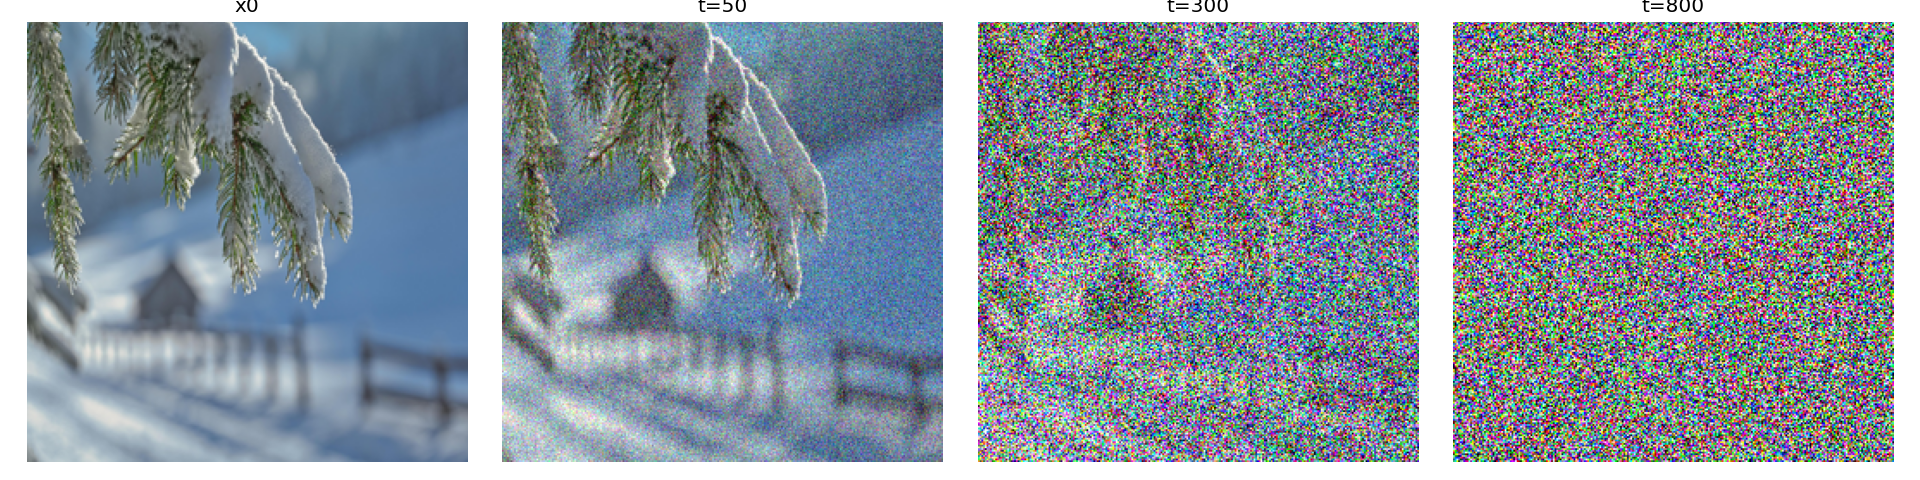

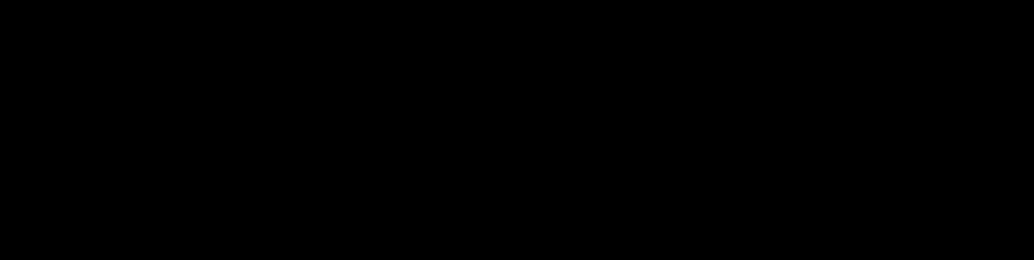

In [27]:
from IPython.display import Image, display

# replace with whichever files you saw from the ls command
display(Image("/content/drive/MyDrive/CSE499A_Project/Week4/results/week4_forward_noising.png"))
display(Image("/content/drive/MyDrive/CSE499A_Project/Week4/results/week4_ddpm_samples.png"))
